In [9]:
import torch
import torchvision
from torchvision import transforms, models

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
import copy
import datetime
import random
import traceback
from IPython.display import display, clear_output
import os
import shutil
from torchvision.datasets import ImageFolder

seed = 0
random.seed(seed)
np.random.seed(seed)

torch.random.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.backends.cudnn.deterministic=False
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [10]:
train_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

val_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

batch_size = 8

trainset = torchvision.datasets.MNIST(root='./data/', train=True, download=True, transform=train_transforms)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)

testset = torchvision.datasets.MNIST(root='./data/', train=False, download=True, transform=val_transforms)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)

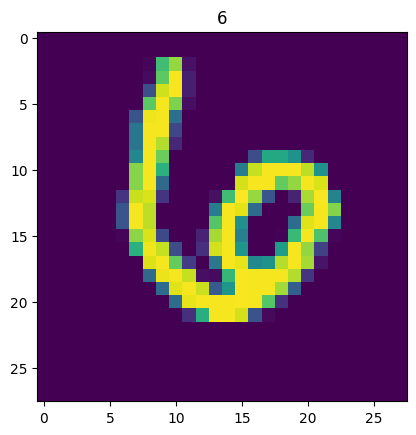

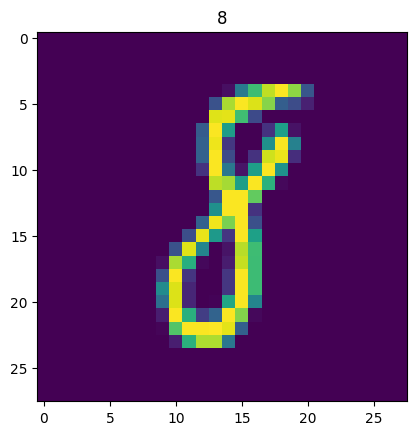

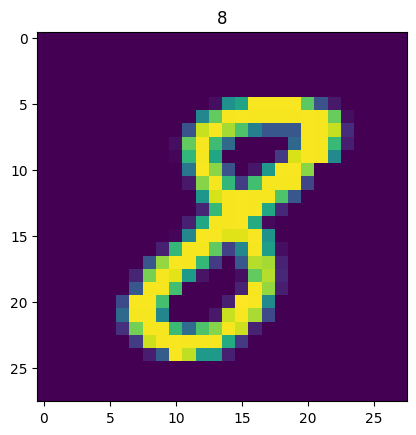

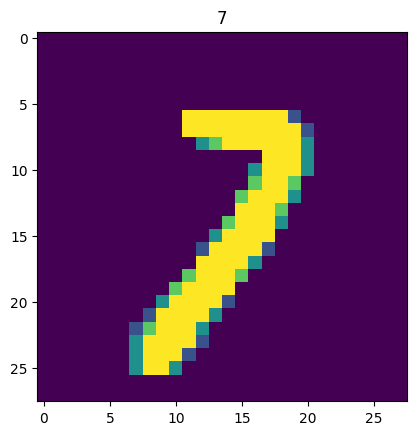

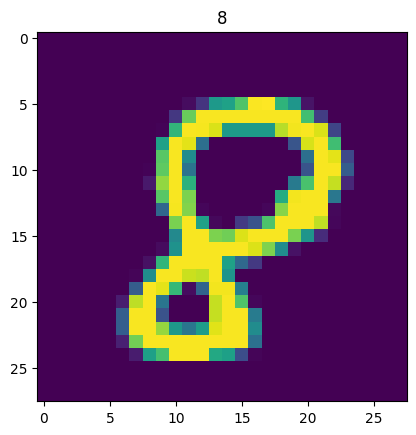

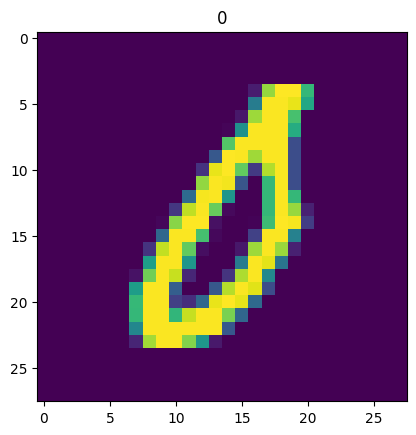

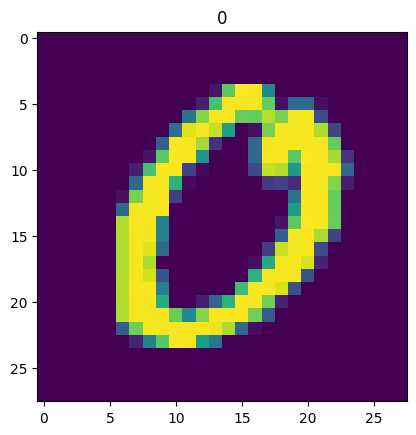

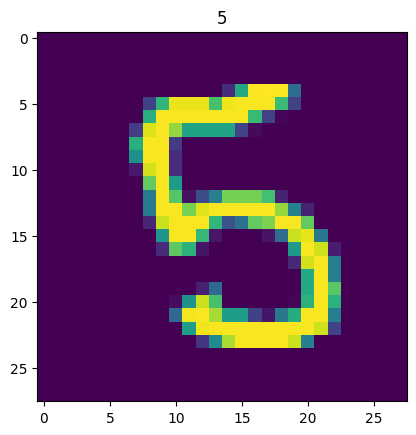

In [11]:
X_batch, y_batch = next(iter(trainloader))
for ind in range(batch_size):
    plt.title(y_batch[ind].numpy())
    plt.imshow(X_batch[ind].permute(1, 2, 0).numpy())
    plt.show()

In [12]:
class fc(torch.nn.Module):
    # Конструктор для класса
    # Инициализация нейронной сети
    def __init__(self):

        super(fc, self).__init__()

        self.fc1 = torch.nn.Linear(784, 256)
        self.activ1 = torch.nn.ReLU()
        self.fc2 = torch.nn.Linear(256, 128)
        self.activ2 = torch.nn.ReLU()
        self.fc3 = torch.nn.Linear(128, 64)
        self.activ3 = torch.nn.ReLU()
        self.fc4 = torch.nn.Linear(64, 32)
        self.activ4 = torch.nn.ReLU()
        self.fc5 = torch.nn.Linear(32, 16)
        self.activ5 = torch.nn.ReLU()
        self.fc6 = torch.nn.Linear(16, 10)
        self.sm = torch.nn.Softmax(dim=1)

    def forward(self, data_input):
        x = data_input.reshape(-1, 784)
        x = self.fc1(x)
        x = self.activ1(x)
        x = self.fc2(x)
        x = self.activ2(x)
        x = self.fc3(x)
        x = self.activ3(x)
        x = self.fc4(x)
        x = self.activ4(x)
        x = self.fc5(x)
        x = self.activ5(x)
        x = self.fc6(x)
        return x

    def inference(self, data_input):
        with torch.no_grad():
            x = self.forward(data_input)
            x = self.sm(x)
        return x

In [13]:
def copy_data_to_device(data, device):
    if torch.is_tensor(data):
        return data.to(device)
    elif isinstance(data, (list, tuple)):
        return [copy_data_to_device(elem, device) for elem in data]
    raise ValueError('Недопустимый тип данных {}'.format(type(data)))

In [14]:
def train_eval_loop(model, train_dataset, val_dataset, criterion,
                    lr=1e-4, epoch_n=10, batch_size=32,
                    device=None, early_stopping_patience=10, l2_reg_alpha=0,
                    max_batches_per_epoch_train=10000,
                    max_batches_per_epoch_val=1000,
                    data_loader_ctor=torch.utils.data.DataLoader,
                    optimizer_ctor=None,
                    lr_scheduler_ctor=None,
                    shuffle_train=True,
                    dataloader_workers_n=0, 
                    plot=False):
    if device is None:
        device = 'cuda' if torch.cuda.is_available() else 'cpu'
    device = torch.device(device)
    model.to(device)

    if optimizer_ctor is None:
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=l2_reg_alpha)
    else:
        optimizer = optimizer_ctor(model.parameters(), lr=lr)

    if lr_scheduler_ctor is not None:
        lr_scheduler = lr_scheduler_ctor(optimizer)
    else:
        lr_scheduler = None

    train_dataloader = data_loader_ctor(train_dataset, batch_size=batch_size, shuffle=shuffle_train,
                                        num_workers=dataloader_workers_n)
    val_dataloader = data_loader_ctor(val_dataset, batch_size=batch_size, shuffle=False,
                                      num_workers=dataloader_workers_n)

    best_val_loss = float('inf')
    best_epoch_i = 0
    best_model = copy.deepcopy(model)

# Dynamic plot
    if plot:
        plot_epoch_data = []
        plot_train_loss = []
        plot_val_loss = []
        plot_acc_train = []
        plot_acc_val = []
        
        fig, ax = plt.subplots(2,1, figsize=(10,6))
        line_train, = ax[0].plot([], [], 'r-')
        line_val, = ax[0].plot([], [], 'b-')
        line_acc_train, = ax[1].plot([], [], 'r-')
        line_acc_val, = ax[1].plot([], [], 'b-')
        ax[0].legend(['train', 'val'])
        ax[0].set_xlim(0, epoch_n)
        ax[1].legend(['train', 'val'])
        ax[1].set_xlim(0, epoch_n)
        ax[0].title.set_text('Функции потерь')
        ax[1].title.set_text('Accuracy')

        def add_point(epoch_i, train_loss, val_loss, acc_train, acc_val):
            max_loss = max(ax[0].viewLim.y1 / 1.1, train_loss, val_loss)
            max_acc = max(ax[1].viewLim.y1 / 1.1, acc_train, acc_val)
            ax[0].set_ylim(0, max_loss * 1.1)
            ax[1].set_ylim(0, 1)
            plot_epoch_data.append(epoch_i)
            plot_train_loss.append(train_loss)
            plot_val_loss.append(val_loss)
            plot_acc_train.append(acc_train)
            plot_acc_val.append(acc_val)
            line_train.set_data(plot_epoch_data, plot_train_loss)
            line_val.set_data(plot_epoch_data, plot_val_loss)
            line_acc_train.set_data(plot_epoch_data, plot_acc_train)
            line_acc_val.set_data(plot_epoch_data, plot_acc_val)
            clear_output(wait=True)
            display(fig)


    for epoch_i in range(epoch_n):
        try:
            epoch_start = datetime.datetime.now()
            

            print('Эпоха {}'.format(epoch_i))

            model.train()
            mean_train_loss = 0
            mean_train_acc = 0
            train_batches_n = 0
            for batch_i, (batch_x, batch_y) in enumerate(train_dataloader):
                if batch_i > max_batches_per_epoch_train:
                    break
                batch_x = copy_data_to_device(batch_x, device)
                batch_y = copy_data_to_device(batch_y, device)

                pred = model(batch_x)
                loss = criterion(pred, batch_y)
                model.zero_grad()
                loss.backward()

                optimizer.step()
                temp = []
                for i in range(len(pred)):
                    temp.append(torch.argmax(pred[i]).cpu().numpy())
                acc = accuracy_score(temp, batch_y.cpu().numpy())
                mean_train_loss += float(loss)
                mean_train_acc += float(acc)
                train_batches_n += 1
                
            
            mean_train_loss /= train_batches_n
            mean_train_acc /= train_batches_n

            print('Эпоха: {} итераций, {:0.2f} сек'.format(train_batches_n,
                                                           (datetime.datetime.now() - epoch_start).total_seconds()))
            print('Среднее значение функции потерь на обучении', mean_train_loss)
            print('Средняя accuracy на обучении', mean_train_acc)



            model.eval()
            mean_val_loss = 0
            mean_val_acc = 0
            val_batches_n = 0

            with torch.no_grad():
                for batch_i, (batch_x, batch_y) in enumerate(val_dataloader):
                    if batch_i > max_batches_per_epoch_val:
                        break

                    batch_x = copy_data_to_device(batch_x, device)
                    batch_y = copy_data_to_device(batch_y, device)

                    pred = model(batch_x)
                    loss = criterion(pred, batch_y)
                    temp = []
                    for i in range(len(pred)):
                        temp.append(torch.argmax(pred[i]).cpu().numpy())
                    acc = accuracy_score(temp, batch_y.cpu().numpy())
                    mean_val_loss += float(loss)
                    mean_val_acc += float(acc)
                    val_batches_n += 1

            mean_val_loss /= val_batches_n
            mean_val_acc /= val_batches_n

            if plot:
                add_point(epoch_i, mean_train_loss, mean_val_loss, mean_train_acc, mean_val_acc)
            else:
                pass
            
            print('Среднее значение функции потерь на валидации', mean_val_loss)
            print('Среднее значение accuracy на валидации', mean_val_acc)

            if mean_val_loss < best_val_loss:
                best_epoch_i = epoch_i
                best_val_loss = mean_val_loss
                best_model = copy.deepcopy(model)
                print('Новая лучшая модель! На эпохе {}'.format(epoch_i))
            elif epoch_i - best_epoch_i > early_stopping_patience:
                print('Модель не улучшилась за последние {} эпох, прекращаем обучение'.format(
                    early_stopping_patience))
                break

            if lr_scheduler is not None:
                lr_scheduler.step(mean_val_loss)

            print()
        except KeyboardInterrupt:
            print('Досрочно остановлено пользователем')
            break
        except Exception as ex:
            print('Ошибка при обучении: {}\n{}'.format(ex, traceback.format_exc()))
            break
        finally:
            if plot:
                plt.close(fig)

    return best_val_loss, best_model


def predict_with_model(model, dataset, device=None, batch_size=32, num_workers=0, return_labels=False):
    if device is None:
        device = 'cuda' if torch.cuda.is_available() else 'cpu'
    results_by_batch = []

    device = torch.device(device)
    model.to(device)
    model.eval()

    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
    labels = []
    with torch.no_grad():
        import tqdm
        for batch_x, batch_y in tqdm.tqdm(dataloader, total=len(dataset)/batch_size):
            batch_x = copy_data_to_device(batch_x, device)

            if return_labels:
                labels.append(batch_y.numpy())

            batch_pred = model(batch_x)
            results_by_batch.append(batch_pred.detach().cpu().numpy())

    if return_labels:
        return np.concatenate(results_by_batch, 0), np.concatenate(labels, 0)
    else:
        return np.concatenate(results_by_batch, 0)

In [15]:
model = fc()

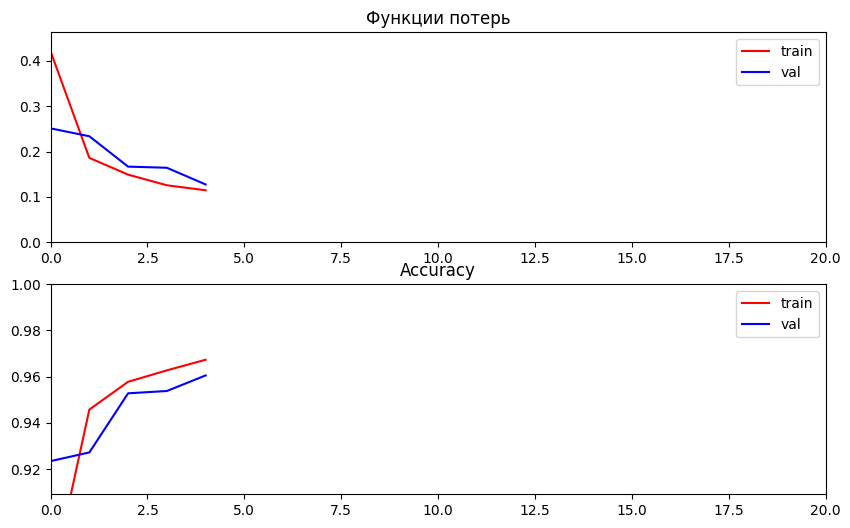

Среднее значение функции потерь на валидации 0.12757080447651728
Среднее значение accuracy на валидации 0.9605394605394605
Новая лучшая модель! На эпохе 4

Эпоха 5


In [ ]:
best_loss, best_model = train_eval_loop(model=model, 
                train_dataset=trainset, 
                val_dataset=testset, 
                criterion=torch.nn.CrossEntropyLoss(),
                lr=1e-3, 
                epoch_n=20, 
                batch_size=batch_size,
                device=device, 
                l2_reg_alpha=0.1,
                max_batches_per_epoch_train=10000,
                max_batches_per_epoch_val=1000,
                optimizer_ctor=torch.optim.Adam,
                data_loader_ctor=torch.utils.data.DataLoader,
                lr_scheduler_ctor=torch.optim.lr_scheduler.ReduceLROnPlateau,
                shuffle_train=True,
                dataloader_workers_n=2,
                plot=True)

In [ ]:
predicted_labels = []
actual_labels = []

model.eval()
with torch.inference_mode():
    for images, labels in testloader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        predicted_labels.extend(predicted.cpu().numpy())
        actual_labels.extend(labels.cpu().numpy())

In [ ]:
accuracy = accuracy_score(actual_labels, predicted_labels)
precision = precision_score(actual_labels, predicted_labels, average='weighted', zero_division=0)
recall = recall_score(actual_labels, predicted_labels, average='weighted', zero_division=0)
f1 = f1_score(actual_labels, predicted_labels, average='weighted', zero_division=0)

# Принт метрик
print(f"Model Accuracy: {accuracy * 100:.2f}%")
print(f"Model Precision: {precision * 100:.2f}%")
print(f"Model Recall: {recall * 100:.2f}%")
print(f"Model F1 Score: {f1 * 100:.2f}%")

cm = confusion_matrix(actual_labels, predicted_labels)
class_names = testloader.dataset.classes

plt.figure(figsize=(10, 10))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues', annot_kws={"size": 15})
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.show()

In [ ]:
df = pd.DataFrame({'preds':predicted_labels, 'actual':actual_labels})
df['err'] = abs(df.preds - df.actual)

In [ ]:
df.query('err > 0')

In [ ]:
i = 0
for el in iter(testloader):
    for j in range(batch_size):
        if i + j in df.query('err > 0').index and i + j < 300:
            image = el[0][j]
            if image.shape[0] == 1:
                image = image[0, ...]
            plt.imshow(image)
            plt.title(f'Предсказали: {df.loc[i+j,"preds"]}; Настоящее: {df.loc[i+j,"actual"]}')
    i+=batch_size
    plt.show()

In [ ]:
Image.open("/kaggle/input/brain-mri-images-for-brain-tumor-detection/no/1 no.jpeg").width,\
Image.open("/kaggle/input/brain-mri-images-for-brain-tumor-detection/no/1 no.jpeg").height

In [ ]:
train_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
    transforms.Resize((224,224)),
    transforms.Grayscale()
])

val_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
    transforms.Resize((224,224)),
    transforms.Grayscale()
])

In [ ]:
class fc2(torch.nn.Module):
    # Конструктор для класса
    # Инициализация нейронной сети
    def __init__(self):

        super(fc2, self).__init__()

        self.fc1 = torch.nn.Linear(224*224, 512)
        self.activ1 = torch.nn.ReLU()
        self.fc2 = torch.nn.Linear(512, 128)
        self.activ2 = torch.nn.ReLU()
        self.fc3 = torch.nn.Linear(128, 64)
        self.activ3 = torch.nn.ReLU()
        self.fc4 = torch.nn.Linear(64, 30)
        self.activ4 = torch.nn.ReLU()
        self.fc5 = torch.nn.Linear(30, 10)
        self.activ5 = torch.nn.ReLU()
        self.fc6 = torch.nn.Linear(10, 2)
        self.sm = torch.nn.Softmax(dim=1)

    def forward(self, data_input):
        x = data_input.reshape(-1, 224*224)
        x = self.fc1(x)
        x = self.activ1(x)
        x = self.fc2(x)
        x = self.activ2(x)
        x = self.fc3(x)
        x = self.activ3(x)
        x = self.fc4(x)
        x = self.activ4(x)
        x = self.fc5(x)
        x = self.activ5(x)
        x = self.fc6(x)
        return x

    def inference(self, data_input):
        with torch.no_grad():
            x = self.forward(data_input)
            x = self.sm(x)
        return x

In [ ]:
!mkdir train val

In [ ]:
!mkdir train/no train/yes val/no val/yes

In [ ]:
class_names = ['no', 'yes']

In [ ]:
files_dir = "/kaggle/input/brain-mri-images-for-brain-tumor-detection"

In [ ]:
i, j = 0, 0
for class_name in class_names:
    if class_name == "no":
        for filename in os.listdir(files_dir + '/'+class_name):
            i+=1
            if filename.endswith('.jpeg') or filename.endswith('.jpg') or filename.endswith('.JPG'):
                file_path = files_dir+'/'+class_name+'/'+filename
                if i < 98*0.8:
                    shutil.copy(file_path, '/kaggle/working/train/' + class_name)
                else:
                    shutil.copy(file_path, '/kaggle/working/val/' + class_name)
    else:
        for filename in os.listdir(files_dir + '/'+class_name):
            j+=1
            if filename.endswith('.jpeg') or filename.endswith('.jpg') or filename.endswith('.JPG'):
                file_path = files_dir+'/'+class_name+'/'+filename
                if j < 155*0.8:
                    shutil.copy(file_path, '/kaggle/working/train/' + class_name)
                else:
                    shutil.copy(file_path, '/kaggle/working/val/' + class_name)

In [ ]:
train_data = ImageFolder(root='/kaggle/working/train', transform=train_transforms)
validation_data = ImageFolder(root='/kaggle/working/val', transform=val_transforms)

In [ ]:
batch_size = 4

In [ ]:
train_dataloader = torch.utils.data.DataLoader(dataset=train_data, batch_size=batch_size, shuffle=True, num_workers=2)
validation_dataloader = torch.utils.data.DataLoader(dataset=validation_data, batch_size=batch_size, shuffle=False, num_workers=2)

In [ ]:
model = fc2()

In [ ]:
best_loss, best_model = train_eval_loop(model=model, 
                train_dataset=train_data, 
                val_dataset=validation_data, 
                criterion=torch.nn.CrossEntropyLoss(),
                lr=1e-3, 
                epoch_n=20, 
                batch_size=batch_size,
                device=device, 
                l2_reg_alpha=0.1,
                max_batches_per_epoch_train=10000,
                max_batches_per_epoch_val=1000,
                optimizer_ctor=torch.optim.Adam,
                data_loader_ctor=torch.utils.data.DataLoader,
                lr_scheduler_ctor=torch.optim.lr_scheduler.ReduceLROnPlateau,
                shuffle_train=True,
                dataloader_workers_n=2,
                plot=True)

In [ ]:
predicted_labels = []
actual_labels = []

model.eval()
with torch.inference_mode():
    for images, labels in validation_dataloader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        predicted_labels.extend(predicted.cpu().numpy())
        actual_labels.extend(labels.cpu().numpy())

In [ ]:
accuracy = accuracy_score(actual_labels, predicted_labels)
precision = precision_score(actual_labels, predicted_labels, average='weighted', zero_division=0)
recall = recall_score(actual_labels, predicted_labels, average='weighted', zero_division=0)
f1 = f1_score(actual_labels, predicted_labels, average='weighted', zero_division=0)

# Принт метрик
print(f"Model Accuracy: {accuracy * 100:.2f}%")
print(f"Model Precision: {precision * 100:.2f}%")
print(f"Model Recall: {recall * 100:.2f}%")
print(f"Model F1 Score: {f1 * 100:.2f}%")

cm = confusion_matrix(actual_labels, predicted_labels)
class_names = validation_dataloader.dataset.classes

plt.figure(figsize=(10, 10))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues', annot_kws={"size": 15})
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.show()

In [ ]:
df = pd.DataFrame({'preds':predicted_labels, 'actual':actual_labels})
df['err'] = abs(df.preds - df.actual)

In [ ]:
df.query('err > 0')

In [ ]:
i = 0
for el in iter(validation_dataloader):
    for j in range(batch_size):
        if i + j in df.query('err > 0').index and i + j < 300:
            image = el[0][j]
            if image.shape[0] == 1:
                image = image[0, ...]
            plt.imshow(image)
            plt.title(f'Предсказали: {df.loc[i+j,"preds"]}; Настоящее: {df.loc[i+j,"actual"]}')
            plt.show()
    i+=batch_size

In [ ]:
class fc3(torch.nn.Module):
    # Конструктор для класса
    # Инициализация нейронной сети
    def __init__(self):

        super(fc2, self).__init__()

        self.fc1 = torch.nn.Linear(224*224, 512)
        self.activ1 = torch.nn.Sigmoid()
        self.fc2 = torch.nn.Linear(512, 128)
        self.activ2 = torch.nn.Sigmoid()
        self.fc3 = torch.nn.Linear(128, 64)
        self.activ3 = torch.nn.Sigmoid()
        self.fc4 = torch.nn.Linear(64, 30)
        self.activ4 = torch.nn.Sigmoid()
        self.fc5 = torch.nn.Linear(30, 10)
        self.activ5 = torch.nn.Sigmoid()
        self.fc6 = torch.nn.Linear(10, 2)
        self.sm = torch.nn.Softmax(dim=1)

    def forward(self, data_input):
        x = data_input.reshape(-1, 224*224)
        x = self.fc1(x)
        x = self.activ1(x)
        x = self.fc2(x)
        x = self.activ2(x)
        x = self.fc3(x)
        x = self.activ3(x)
        x = self.fc4(x)
        x = self.activ4(x)
        x = self.fc5(x)
        x = self.activ5(x)
        x = self.fc6(x)
        return x

    def inference(self, data_input):
        with torch.no_grad():
            x = self.forward(data_input)
            x = self.sm(x)
        return x

In [ ]:
model = fc3()

In [ ]:
best_loss, best_model = train_eval_loop(model=model, 
                train_dataset=train_data, 
                val_dataset=validation_data, 
                criterion=torch.nn.CrossEntropyLoss(),
                lr=1e-3, 
                epoch_n=20, 
                batch_size=batch_size,
                device=device, 
                l2_reg_alpha=0.1,
                max_batches_per_epoch_train=10000,
                max_batches_per_epoch_val=1000,
                optimizer_ctor=torch.optim.Adam,
                data_loader_ctor=torch.utils.data.DataLoader,
                lr_scheduler_ctor=torch.optim.lr_scheduler.ReduceLROnPlateau,
                shuffle_train=True,
                dataloader_workers_n=2,
                plot=True)

In [ ]:
predicted_labels = []
actual_labels = []

model.eval()
with torch.inference_mode():
    for images, labels in validation_dataloader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        predicted_labels.extend(predicted.cpu().numpy())
        actual_labels.extend(labels.cpu().numpy())

In [ ]:
accuracy = accuracy_score(actual_labels, predicted_labels)
precision = precision_score(actual_labels, predicted_labels, average='weighted', zero_division=0)
recall = recall_score(actual_labels, predicted_labels, average='weighted', zero_division=0)
f1 = f1_score(actual_labels, predicted_labels, average='weighted', zero_division=0)

# Принт метрик
print(f"Model Accuracy: {accuracy * 100:.2f}%")
print(f"Model Precision: {precision * 100:.2f}%")
print(f"Model Recall: {recall * 100:.2f}%")
print(f"Model F1 Score: {f1 * 100:.2f}%")

cm = confusion_matrix(actual_labels, predicted_labels)
class_names = validation_dataloader.dataset.classes

plt.figure(figsize=(10, 10))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues', annot_kws={"size": 15})
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.show()

In [ ]:
df = pd.DataFrame({'preds':predicted_labels, 'actual':actual_labels})
df['err'] = abs(df.preds - df.actual)

In [ ]:
df.query('err > 0')

In [ ]:
i = 0
for el in iter(validation_dataloader):
    for j in range(batch_size):
        if i + j in df.query('err > 0').index:
            image = el[0][j]
            if image.shape[0] == 1:
                image = image[0, ...]
            plt.imshow(image)
            plt.title(f'Предсказали: {df.loc[i+j,"preds"]}; Настоящее: {df.loc[i+j,"actual"]}')
            plt.show()
    i+=batch_size

In [ ]:
#!rm -rf train val